## PARIS inverse modelling results

This notebook contains options to plot and compare results from different inverse models. These variables can all be investigated:

- Posterior and prior country fluxes, total from all sectors
- Posterior, prior and observed modelled total mole fractions
- Posterior and prior modelled baseline mole fractions
- Posterior and prior spatial fluxes

Future updates may include:

- Sector-level emissions
- Comparison between each model's country/region definition

### Notebook setup:

1. Edit the `data_dir` to point towards where the model output is.

2. Update the `model_filenames` dictionary to point towards the experiment/model you want to plot. Update the `model_labels` and `model_colors` dictionaries, these change how each model is labelled in the plots.

3. Run the cell below, before running any of the plotting code.

In [57]:
%load_ext autoreload
%autoreload 2
import PARIS_inversion_results as func

#data_dir = '/project/InTEM_GHG/inversion/PARIS_results_sharing/'
data_dir = '/home/h02/aramsden/results/multi_gas_MCMC/processed_output/'

model_filenames = {'rhime':'RHIME_NAME_EUROPE_EDGAR_rhime_obs_rhime_baseline_optimized_33sites*',
                  'rhime_edgar_allobs':'RHIME_NAME_EUROPE_EDGAR_all_obs*',
                  'mcmc_oldflux':'MCMC_NAME_EUROPE_250basis*',
                  'mcmc_2gas':'MCMC_NAME_EUROPE_2sector-2gas_250basis_std-uncert*',
                  'mcmc':'MCMC_NAME_EUROPE_mean_250basis_std-uncert*',
                  'mcmc_prop-uncert':'MCMC_NAME_EUROPE_mean_250basis_prop-uncert*',
                  'mcmc_prop-uncert-high-MHDbc_fixed-outer_filtered':'MCMC_NAME_EUROPE_mean-MHD25perc-mask-outer_250basis_prop-uncert-high-x-uncert-filtered',
                  'mcmc_prop-uncert-high':'MCMC_NAME_EUROPE_mean_250basis_prop-uncert-high-x-uncert*',
                  'mcmc_prop-uncert-high-MHDbc':'MCMC_NAME_EUROPE_mean-MHD25perc_250basis_prop-uncert-high-x-uncert*',
                  'mcmc_prop-uncert-MHDbc-fixed-outer':'MCMC_NAME_EUROPE_mean-MHD25perc-mask-outer_250basis_prop-uncert',
                  'mcmc_prop-uncert-high-MHDbc_fixed-outer':'MCMC_NAME_EUROPE_mean-MHD25perc-mask-outer_250basis_prop-uncert-high-x-uncert*',
                  'mcmc_prop-uncert-highbc-MHDbc_fixed-outer':'MCMC_NAME_EUROPE_mean-MHD25perc-mask-outer_250basis_prop-uncert-high-xbc-uncert*',
                  'mcmc_new-setup':'MCMC_NAME_EUROPE_mean-MHD25perc-mask-outer_250basis_prop-uncert-high-x-uncert-filtered',
                  'mcmc_new-setup_total2_uncert2':'MCMC_NAME_EUROPE_total2_new-setup_uncert2',
                  'mcmc_new-setup_total2_uncert05':'MCMC_NAME_EUROPE_total2_new-setup_uncert05',
                  'mcmc_new-setup_total05_uncert2':'MCMC_NAME_EUROPE_total05_new-setup_uncert2',
                  'mcmc_new-setup_total05_uncert05':'MCMC_NAME_EUROPE_total05_new-setup_uncert05',
                  'mcmc_new-setup_total2_uncert2_fixedbc':'MCMC_NAME_EUROPE_total2_new-setup_uncert2-fixedbc',
                  'mcmc_new-setup_total2_uncert05_fixedbc':'MCMC_NAME_EUROPE_total2_new-setup_uncert05-fixedbc',
                  'mcmc_new-setup_total05_uncert2_fixedbc':'MCMC_NAME_EUROPE_total05_new-setup_uncert2-fixedbc',
                  'mcmc_new-setup_total05_uncert05_fixedbc':'MCMC_NAME_EUROPE_total05_new-setup_uncert05-fixedbc',
                  'mcmc_new-setup_fixedbc':'MCMC_NAME_EUROPE_total_new-setup-fixedbc',
                  'mcmc_fixedbc':'MCMC_NAME_EUROPE_total_fixedbc',
                  'mcmc_fixedbc_2gas':'MCMC_NAME_EUROPE_total_fixedbc_2gas',
                  'intem':'InTEM_NAME_EUROPE_5UK_site_test*',
                  'intem_33site':'InTEM_NAME_EUROPE_Jan2024*'}

model_labels = {'rhime':'RHIME 33 site',
                  'rhime_edgar_allobs':'RHIME EDGAR all obs',
                  'mcmc_oldflux':'MCMC old flux',
                  'mcmc_2gas':'MCMC 2 gas',
                  'mcmc':'MCMC old $\sigma$, 50% uncert',
                  'mcmc_prop-uncert':'MCMC 50% uncert',
                  'mcmc_prop-uncert-high-MHDbc_fixed-outer_filtered':'MCMC 200% uncert\nMHD bc, fixed basis, filtered',
                  'mcmc_prop-uncert-high':'MCMC 200% uncert',
                  'mcmc_prop-uncert-high-MHDbc':'MCMC 200% uncert, MHD bc',
                  'mcmc_prop-uncert-MHDbc-fixed-outer':'MCMC, MHD bc, fixed outer',
                  'mcmc_prop-uncert-high-MHDbc_fixed-outer':'MCMC 200% uncert,\nMHD bc, fixed basis',
                  'mcmc_prop-uncert-highbc-MHDbc_fixed-outer':'MCMC 200% uncert,100% bc uncert\nMHD bc, fixed basis',
                  'mcmc_new-setup':'MCMC total, 200% uncert',
                  'mcmc_new-setup_total2_uncert2':'MCMC totalx2, 200% uncert',
                  'mcmc_new-setup_total2_uncert05':'MCMC totalx2, 50% uncert',
                  'mcmc_new-setup_total05_uncert2':'MCMC total/2, 200% uncert',
                  'mcmc_new-setup_total05_uncert05':'MCMC total/2, 50% uncert',
                  'mcmc_new-setup_total2_uncert2_fixedbc':'MCMC totalx2, 200% uncert, fixed BC',
                  'mcmc_new-setup_total2_uncert05_fixedbc':'MCMC totalx2, 50% uncert, fixed BC',
                  'mcmc_new-setup_total05_uncert2_fixedbc':'MCMC total/2, 200% uncert, fixed BC',
                  'mcmc_new-setup_total05_uncert05_fixedbc':'MCMC total/2, 50% uncert, fixed BC',
                  'mcmc_new-setup_fixedbc':'MCMC 200% uncert, fixed BC',
                  'mcmc_fixedbc':'MCMC fixed BC CH4',
                  'mcmc_fixedbc_2gas':'MCMC fixed BC CH4 + C2H6',
                  'intem':'InTEM 5 site',
                  'intem_33site':'InTEM 33 site'}

model_colors = {'rhime':['dimgrey','grey'],
                'rhime_edgar_allobs':['orange','gold'],
                'mcmc_oldflux':['teal','darkturquoise'],
                'mcmc_2gas':['purple','mediumpurple'],
                'mcmc':['teal','darkturquoise'],
                'mcmc_prop-uncert-high-MHDbc_fixed-outer_filtered':['darkblue','dodgerblue'],
                'mcmc_prop-uncert':['purple','mediumpurple'],
                   'mcmc_prop-uncert-high':['firebrick','darkorange'],
                   'mcmc_prop-uncert-high-MHDbc':['darkblue','dodgerblue'],
                   'mcmc_prop-uncert-high-MHDbc_fixed-outer':['darkblue','dodgerblue'],
                   'mcmc_prop-uncert-highbc-MHDbc_fixed-outer':['darkblue','dodgerblue'],
                   'mcmc_prop-uncert-MHDbc-fixed-outer':['darkblue','dodgerblue'],
                   'mcmc_new-setup':['darkblue','dodgerblue'],
                  'mcmc_new-setup_total2_uncert2':['purple','mediumpurple'],
                  'mcmc_new-setup_total2_uncert05':['orange','goldenrod'],
                  'mcmc_new-setup_total05_uncert2':['firebrick','darkorange'],
                  'mcmc_new-setup_total05_uncert05':['teal','darkturquoise'],
                  'mcmc_new-setup_total2_uncert2_fixedbc':['purple','mediumpurple'],
                  'mcmc_new-setup_total2_uncert05_fixedbc':['orange','goldenrod'],
                  'mcmc_new-setup_total05_uncert2_fixedbc':['firebrick','darkorange'],
                  'mcmc_new-setup_total05_uncert05_fixedbc':['teal','darkturquoise'],
                  'mcmc_new-setup_fixedbc':['dimgrey','grey'],
                  'mcmc_fixedbc':['purple','mediumpurple'],
                  'mcmc_fixedbc_2gas':['teal','darkturquoise'],
                'intem':['orange','goldenrod'],
                'intem_33site':['purple','mediumpurple']}

NOTE: If plotting units or scales look odd, edit species_info.json to fix this.
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### 1. Timeseries of country/region fluxes

##### Edit and run this cell to choose inputs:

In [58]:
###################################
### edit variables in this block
species = 'ch4' #'hfc125'
plot_regions = ['UK','FRANCE','GERMANY','IRELAND'] #works best with 6 countries but can run with any number (will always create at least 4 subplots though)
#models = ['intem_edgar','intem_flat','intem_oldflat']
#models = ['intem_edgar','intem_edgar_allobs']
#models = ['intem_edgar','elris_edgar','rhime_edgar']
#models = ['intem_edgar','intem_edgar_allobs','rhime_edgar','rhime_edgar_allobs']
#models = ['intem_flat','elris_flat']
#models = ['intem_flat','elris_flat','intem_edgar','elris_edgar',]
#models = ['intem_edgar','elris_edgar','rhime_edgar']
#models = ['intem','intem_33site','mcmc','mcmc_prop-uncert-high-MHDbc_fixed-outer_filtered']
#models = ['intem','mcmc_new-setup','mcmc_new-setup_total2_uncert2','mcmc_new-setup_total2_uncert05',
#         'mcmc_new-setup_total05_uncert2','mcmc_new-setup_total05_uncert05']
#models = ['intem','mcmc_new-setup','mcmc_new-setup_total2_uncert2_fixedbc','mcmc_new-setup_total2_uncert05_fixedbc',
#         'mcmc_new-setup_total05_uncert2_fixedbc','mcmc_new-setup_total05_uncert05_fixedbc',
#        'mcmc_new-setup_fixedbc']
models = ['intem','mcmc_fixedbc','mcmc_fixedbc_2gas']
#models = ['intem','mcmc','mcmc_2gas']
#models = ['intem','mcmc_prop-uncert','mcmc_prop-uncert-high-MHDbc_fixed-outer','mcmc_prop-uncert-high-MHDbc_fixed-outer_filtered']
period_override = None #use to override standard inversion periods, must be a list the same length as models, e.g. ['monthly','yearly']
start_date = '2018-01-01' #inclusive
end_date = '2020-01-01' #not inclusive
###################################

ds_all_flux = func.read_flux(data_dir,species,models,model_filenames,period_override=period_override)

ds_all_flux_scaled = {}

for m in models:
    ds_all_flux_scaled[m] = func.slice_flux({m:ds_all_flux[m]},start_date,end_date,scale_units=True,
                                species=species)[m]

#ds_all_flux_scaled = func.slice_flux(ds_all_flux,start_date,end_date,scale_units=True,
#                                species=species)


Attempting to read data from intem
Reading data from: /home/h02/aramsden/results/multi_gas_MCMC/processed_output/InTEM/ch4/InTEM_NAME_EUROPE_5UK_site_test_ch4_monthly.nc
Done!

Attempting to read data from mcmc_fixedbc
Reading data from: /home/h02/aramsden/results/multi_gas_MCMC/processed_output/MCMC/ch4/MCMC_NAME_EUROPE_total_fixedbc_ch4_monthly.nc
Done!

Attempting to read data from mcmc_fixedbc_2gas
Reading data from: /home/h02/aramsden/results/multi_gas_MCMC/processed_output/MCMC/ch4/MCMC_NAME_EUROPE_total_fixedbc_2gas_ch4_monthly.nc
Done!

Masking data from intem
Scaling intem units by 1000000000.0

Masking data from mcmc_fixedbc
Scaling mcmc_fixedbc units by 1

Masking data from mcmc_fixedbc_2gas
Scaling mcmc_fixedbc_2gas units by 1


#### Timeseries of country fluxes:

NOTE: If all the data is not within axis limits, adjust the set_ylim parameter


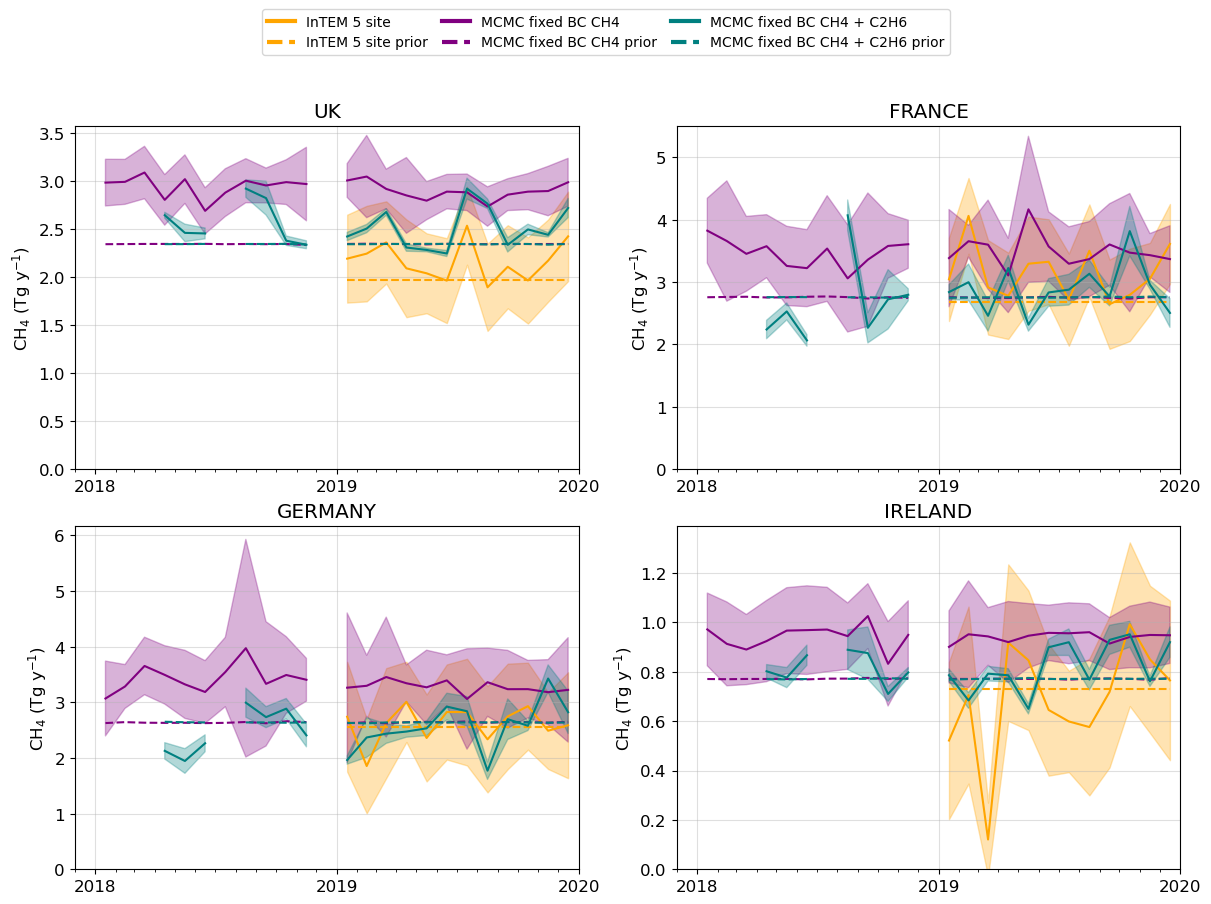

In [59]:
###################################
### edit variables in this block
plot_inventory = False
fix_y_axes = False #if True: all y axis limits are the same, if False: each y axis is relative to the data
                     #if a list of floats (e.g. [0,0.1]) applies these limit to all axes
add_prior_unc = False #if True: plots prior uncertainty as shaded area
set_global_leg = True #If True, plots one single legend instead of one legend per subplot.
###################################

fig = func.plot_country_flux(ds_all_flux_scaled,species,plot_regions,model_labels,
                             model_colors,
                             plot_inventory,data_dir,fix_y_axes,
                             add_prior_unc,set_global_leg)

Save plot here:

In [ ]:
output_path = '/home/h02/aramsden/results/multi_gas_MCMC/code_edits_testing/post-country-fluxes_ch4_2gas_test.png'

fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

### 2. Modelled and observed mole fractions and/or baselines

##### Edit and run this cell to choose inputs and read in the data:

In [ ]:
###################################
### edit variables in this block
species = 'ch4' 
site = 'TAC'
#models = ['intem_edgar','intem_flat','intem_oldflat']
#models = ['intem_edgar','intem_edgar_allobs']
#models = ['intem_flat','elris_flat']
#models = ['intem_edgar','elris_edgar','rhime_edgar']
#models = ['intem','mcmc_new-setup','mcmc_new-setup_total2_uncert2','mcmc_new-setup_total2_uncert05',
#         'mcmc_new-setup_total05_uncert2','mcmc_new-setup_total05_uncert05']
#models = ['intem','mcmc_new-setup','mcmc_new-setup_total2_uncert2_fixedbc','mcmc_new-setup_total2_uncert05_fixedbc',
#         'mcmc_new-setup_total05_uncert2_fixedbc','mcmc_new-setup_total05_uncert05_fixedbc']
#models = ['intem','mcmc_new-setup_total2_uncert2_fixedbc',
#         'mcmc_new-setup_total05_uncert2_fixedbc','mcmc_new-setup_fixedbc']
models = ['intem','mcmc_fixedbc','mcmc_fixedbc_2gas']

#models = ['intem','mcmc_prop-uncert','mcmc_prop-uncert-high-MHDbc_fixed-outer','mcmc_prop-uncert-high-MHDbc_fixed-outer_filtered']
period_override = None #use to override standard inversion periods, must be a list the same length as models, e.g. ['monthly','yearly']
start_date = '2019-01-01' #inclusive
end_date = '2020-01-01'   #not inclusive

baseline_site = None #'MHD', 'JFJ' or 'CMN'. If None, does not mask by baseline time
###################################

###################################
### options for variables to include in the functions below 
# Yobs          - total observed mole fraction
# uYobs         - total observed mole fraction uncertainty
# uYmod         - total model mole fraction uncertainty
# Yapriori      - prior total mole fraction
# Yapost        - posterior total mole fraction
# YaprioriBC    - prior baseline
# YapostBC      - posterior baseline
# Ybias         - posterior bias added to site
# YaprioriOuter - prior mole fractions only from outer regions
# YapostOuter   - posterior mole fractions only from outer regions
###################################

ds_all_mf = func.read_mf(data_dir,species,models,model_filenames,period_override=period_override)

ds_all_mf_sliced = {}

for m in models:
    ds_all_mf_sliced[m] = func.slice_mf({m:ds_all_mf[m]},start_date,end_date,site,baseline_site=baseline_site,
                              data_dir=data_dir,
                              scale_units=True,species=species)[m]

#### Timeseries plot, separated by model:

In [ ]:
fig = func.plot_obs_modelled_separate(ds_all_mf_sliced,species,site,model_labels,
                                      model_colors,
                             include=['Yobs','Yapost'],
                             diff_include=['Yapost'])

###################################
### Instructions for timeseries plotting: 
# - Add variables that you want to plot in "include"
# - To plot the histogram of the variables in "include", leave "diff_include" empty
# - To plot the histogram of Obs-variable, add the desired variable to be subtracted in "diff_include" (default value of "diff_include" = Yapost)
# - To erase uncertainty bars around the mean values of Yobs and Yapost set "add_unc" to False (default value of "add_unc" = True)
###################################

In [ ]:
output_path = '/home/h02/aramsden/results/multi_gas_MCMC/code_edits_testing/YapostBC-TAC_prior-uncert-tests.png'

fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

#### Timeseries plot, all models together:

In [ ]:
fig = func.plot_obs_modelled_together(ds_all_mf_sliced,species,site,model_labels,
                                      model_colors,
                             include=['YapostBC'],
                             diff_include=['YapostBC'])

#### Absolute differences between two models:

In [ ]:
fig = func.plot_obs_diff(ds_all_mf_sliced,species,site,model_labels,
                                      model_colors,
                             include=['Yapost'],
                             diff_include=['Yapost'])

#### Calculate and plot stats for the fit to obs:

In [ ]:
ds_all_allsites = func.slice_mf(ds_all_mf.copy(),start_date,end_date,site=None,
                              baseline_site=baseline_site,
                              data_dir=data_dir,
                              scale_units=True,species=species)

pearson,nrmse = func.stats_mf(ds_all_allsites,species)

fig = func.plot_stats_mf(pearson,nrmse,species,model_labels,
                         model_colors,
                  start_date=start_date,end_date=end_date)

Save plot:

In [ ]:
output_path = None

#fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

### 3. Posterior country fluxes - lat lon grid prior and posterior comparison

##### Edit this cell to choose inputs:

In [2]:
###################################
### edit variables in this block
species = 'ch4'
start_date = '2019-01-01' #select the time period to plot (a month or year, depending on the inversion period)
end_date = '2021-01-01' #if end_date doesn't = start_date, a mean average of the whole period will be plotted
#models = ['intem_edgar','intem_flat','intem_oldflat']
#models = ['intem_edgar','intem_edgar_sapr','intem_flat','intem_flat_sapr']
#models = ['intem_edgar','intem_edgar_allobs']
#models = ['intem_edgar','elris_edgar','rhime_edgar']
#models = ['intem_edgar_sapr','intem_edgar_allobs_sapr','rhime_edgar','rhime_edgar_allobs']
#models = ['intem_flat_sapr','elris_flat','intem_edgar_sapr','elris_edgar']
#models = ['intem','mcmc','mcmc_2gas','mcmc_prop-uncert','mcmc_prop-uncert-high','mcmc_prop-uncert-high-MHDbc_fixed-outer']
#models = ['intem','mcmc_prop-uncert-high','mcmc_prop-uncert-high-MHDbc','mcmc_prop-uncert-high-MHDbc_fixed-outer']
#models = ['intem','mcmc_new-setup','mcmc_new-setup_total2_uncert2','mcmc_new-setup_total2_uncert05',
#         'mcmc_new-setup_total05_uncert2','mcmc_new-setup_total05_uncert05']
models = ['intem','mcmc_fixedbc','mcmc_fixedbc_2gas']
sectors = [['total'],['total'],['FF','nonFF']]
period_override = None #use to override standard inversion periods, must be a list the same length as models, e.g. ['monthly','yearly']
###################################

ds_all_flux = func.read_flux(data_dir,species,models,model_filenames,period_override=period_override)

ds_all_flux_scaled = {}

for m in models:

    ds_all_flux_scaled[m] = func.slice_flux({m:ds_all_flux[m]},start_date,end_date,scale_units=True,
                                    species=species)[m]


Attempting to read data from intem
Reading data from: /home/h02/aramsden/results/multi_gas_MCMC/processed_output/InTEM/ch4/InTEM_NAME_EUROPE_5UK_site_test_ch4_monthly.nc
Done!

Attempting to read data from mcmc_fixedbc
Reading data from: /home/h02/aramsden/results/multi_gas_MCMC/processed_output/MCMC/ch4/MCMC_NAME_EUROPE_total_fixedbc_ch4_monthly.nc
Done!

Attempting to read data from mcmc_fixedbc_2gas
Reading data from: /home/h02/aramsden/results/multi_gas_MCMC/processed_output/MCMC/ch4/MCMC_NAME_EUROPE_total_fixedbc_2gas_ch4_monthly.nc
Done!

Masking data from intem
Scaling intem units by 1000000000.0

Masking data from mcmc_fixedbc
Scaling mcmc_fixedbc units by 1

Masking data from mcmc_fixedbc_2gas
Scaling mcmc_fixedbc_2gas units by 1


##### Prior and posterior fluxes for all models:

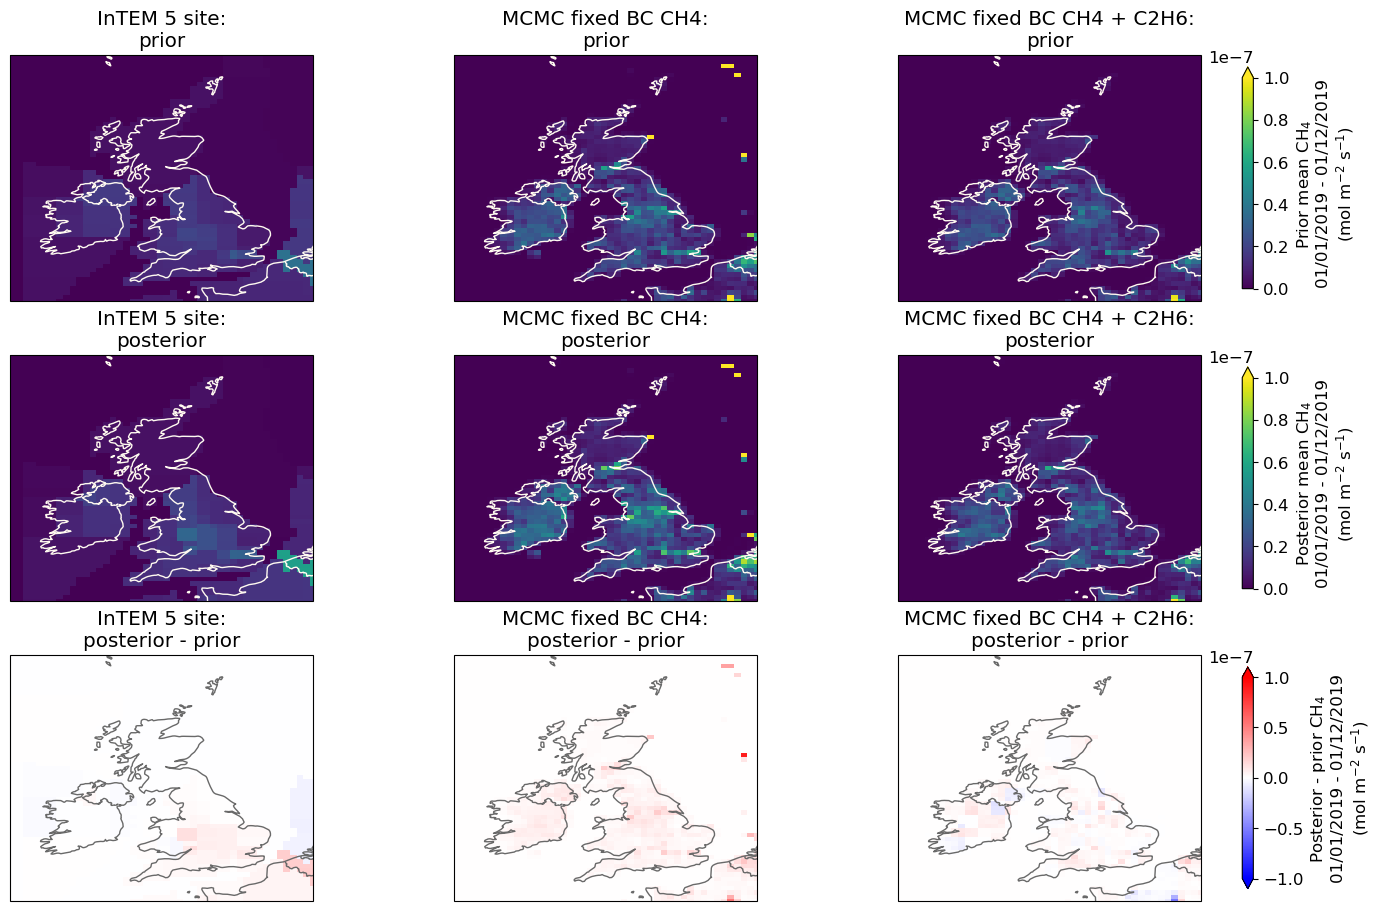

In [6]:
###################################
### edit variables in this block
plot_area = 'UK' #options for: UK, FRANCE, GERMANY, ITALY, SWITZERLAND, NWEU, CWEU, EUROPE
###################################

fig = func.plot_spatial_flux(ds_all_flux_scaled,species,plot_area,model_labels,
                             sectors=sectors,cmap='viridis',
                             cmap_diff='bwr',c_border='floralwhite')

In [ ]:
output_path = '/home/h02/aramsden/results/multi_gas_MCMC/code_edits_testing/spatial-fluxes_ch4_prior_uncert_tests.png'

fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

##### Directly compare posterior fluxes from two models:

In [ ]:
fig = func.plot_spatial_flux_comparison(ds_all_flux_scaled,species,plot_area,model_labels)

### 7. Compare region definitions

THIS NEEDS UPDATING TO COMPARE MULTIPLE MODELS - CURRENTLY THESE NEED TO BE INPUT MANUALLY

In [ ]:
species = 'ch4' #select the species you want to plot
plot_region = 'UK' #choose the region mask to plot

In [ ]:
# Read in emissions output

intem = xr.open_dataset(os.path.join(data_dir,f'InTEM_NAME_EUROPE_{intem_species[species]}_{period[m][species]}.nc'))
#rhime = xr.open_dataset(os.path.join(data_dir,f'RHIME_NAME_EUROPE_{species}_{period}.nc'))
#empa = xr.open_dataset(os.path.join(data_dir,f'{empa_name}_FLEXPART_EUROPE_{species}_{period}.nc')) 

try:
    intem_r0 = np.where(intem['countrynames'].values == plot_region)[0][0]
except:
    print(f'No region in InTEM called {plot_region}')

In [ ]:
ax_limits = [-12,25,40,65] #min_lon, max_lon, min_lat, max_lat

fig,ax = plt.subplots(2,3,figsize=(12,6),constrained_layout=True,
                          subplot_kw={'projection':cartopy.crs.PlateCarree()})

for i in range(2):
    for j in range(3):
        ax[i,j].add_feature(cartopy.feature.BORDERS,linestyle=':',edgecolor='black',linewidth=1.)
        ax[i,j].coastlines(resolution='50m',color='black',linewidth=1.)
        ax[i,j].set_extent(ax_limits)
        
#plot intem
ax[0,0].pcolormesh(intem.lon.values,intem.lat.values,intem['region_definitions'][:,:,intem_r0],cmap='Blues',
                 vmin=0,vmax=2)
ax[0,0].set_title(f'InTEM {plot_region} mask')

#plot difference
#ax[1,0].pcolormesh(intem.lon.values,intem.lat.values,
#                   intem['region_definitions'][:,:,intem_r0]-rhime['region_definitions'][:,:,rhime_r0],
#                   cmap='bwr')
ax[1,0].set_title(f'InTEM {plot_region} - RHIME {plot_region}')